In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
!nvidia-smi

In [ ]:
import os

for root, dirs, files in os.walk("/kaggle/input/mwpd-pothole-dataset"):
    level = root.replace("/kaggle/input/mwpd-pothole-dataset", "").count(os.sep)
    if level <= 2:
        print(root, len(files))

In [ ]:
print("KAGGLE WORKS")

In [ ]:
import os

print(os.listdir("/kaggle/input"))

In [ ]:
import os
print(os.listdir("/kaggle/input/datasets"))

In [ ]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    if root.count(os.sep) > 4:
        dirs[:] = []

In [ ]:
import os

print(os.listdir("/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset"))

In [ ]:
import os

print(os.listdir("/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD"))

In [ ]:
!git clone https://github.com/WongKinYiu/yolov9.git /kaggle/working/yolov9

In [ ]:
import os

print(os.path.exists("/kaggle/working/yolov9/train_dual.py"))
print(os.path.exists("/kaggle/working/yolov9/models/detect/yolov9-c.yaml"))
print(os.path.exists("/kaggle/working/yolov9/data/hyps/hyp.scratch-high.yaml"))

In [ ]:
%%writefile /kaggle/working/yolov9/data_mwpd.yaml

path: /kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD

train: train/images
val: valid/images
test: test/images

nc: 1
names:
  0: Potholes

In [ ]:
from pathlib import Path

base = Path("/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD")

print("Train:", len(list((base / "train/images").glob("*"))))
print("Valid:", len(list((base / "valid/images").glob("*"))))
print("Test :", len(list((base / "test/images").glob("*"))))

In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU count:", torch.cuda.device_count())

In [ ]:
%cd /kaggle/working/yolov9
!pip install -q -r requirements.txt

In [ ]:
import torch
import torchvision
import cv2
import yaml
import scipy
import albumentations

print("All imports OK")
print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA:", torch.cuda.is_available())

In [ ]:
%cd /kaggle/working/yolov9

!wget -q https://github.com/WongKinYiu/yolov9/releases/download/v0.1/yolov9-c.pt

!ls -lh yolov9-c.pt

In [ ]:
%cd /kaggle/working/yolov9

!python train_dual.py \
  --weights yolov9-c.pt \
  --cfg models/detect/yolov9-c.yaml \
  --data data_mwpd.yaml \
  --hyp data/hyps/hyp.scratch-high.yaml \
  --epochs 1 \
  --batch-size 4 \
  --imgsz 640 \
  --device 0 \
  --workers 2 \
  --optimizer SGD \
  --name mwpd_smoketest \
  --exist-ok

In [ ]:
%cd /kaggle/working/yolov9

!sed -i "s/torch.load(weights, map_location='cpu')/torch.load(weights, map_location='cpu', weights_only=False)/" train_dual.py

In [ ]:
!grep -n "torch.load(weights" train_dual.py

In [ ]:
%cd /kaggle/working/yolov9

!sed -i "s/torch.load(f, map_location=torch.device('cpu'))/torch.load(f, map_location=torch.device('cpu'), weights_only=False)/" utils/general.py

!grep -n "torch.load(f" utils/general.py

In [ ]:
%cd /kaggle/working/yolov9

!grep -n "getsize" utils/plots.py

In [ ]:
%cd /kaggle/working/yolov9

!sed -i 's/self\.font\.getsize(label)/self.font.getbbox(label)[2:4]/' utils/plots.py
!sed -i 's/self\.font\.getsize(text)/self.font.getbbox(text)[2:4]/' utils/plots.py

!grep -n "getbbox" utils/plots.py

In [ ]:
%cd /kaggle/working/yolov9

!python train_dual.py \
  --weights yolov9-c.pt \
  --cfg models/detect/yolov9-c.yaml \
  --data data_mwpd.yaml \
  --hyp data/hyps/hyp.scratch-high.yaml \
  --epochs 1 \
  --batch-size 4 \
  --imgsz 640 \
  --device 0 \
  --workers 2 \
  --optimizer SGD \
  --name mwpd_smoketest \
  --exist-ok

In [ ]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.endswith(".pt"):
            print(os.path.join(root, file))

In [ ]:
import shutil
from pathlib import Path

src = Path("/kaggle/input/datasets/sanjanathanabalan/yolov9-mwpd-baseline-checkpoint/last.pt")
dst = Path("/kaggle/working/yolov9/runs/train/mwpd_yolov9c_baseline/weights/last.pt")

dst.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(src, dst)

print("Checkpoint copied successfully!")
print("Size:", dst.stat().st_size / (1024**2), "MB")

In [ ]:
import torch

ckpt = torch.load(
    "/kaggle/working/yolov9/runs/train/mwpd_yolov9c_baseline/weights/last.pt",
    map_location="cpu",
    weights_only=False
)

print("Checkpoint epoch:", ckpt["epoch"])
print("Best fitness:", ckpt.get("best_fitness"))
print("Checkpoint keys:", ckpt.keys())

In [ ]:
import os
import sys
import torch

os.chdir("/kaggle/working/yolov9")
sys.path.insert(0, "/kaggle/working/yolov9")

ckpt = torch.load(
    "runs/train/mwpd_yolov9c_baseline/weights/last.pt",
    map_location="cpu",
    weights_only=False
)

print("Checkpoint epoch:", ckpt["epoch"])
print("Best fitness:", ckpt.get("best_fitness"))
print("Checkpoint loaded successfully!")

In [ ]:
%cd /kaggle/working/yolov9

import sys
sys.path.insert(0, "/kaggle/working/yolov9")

import models

print("YOLOv9 models imported successfully!")
print("Location:", models.__file__)

In [ ]:
import os
import sys

YOLOV9 = "/kaggle/working/yolov9"

print("YOLOv9 exists:", os.path.exists(YOLOV9))
print("Models folder exists:", os.path.exists(YOLOV9 + "/models"))

os.chdir(YOLOV9)
sys.path.insert(0, YOLOV9)

print("Current directory:", os.getcwd())
print("Python path:", sys.path[0])

import models

print("YOLOv9 models imported successfully!")
print("Location:", models.__file__)

In [ ]:
import os

print(os.listdir("/kaggle/working/yolov9"))

In [ ]:
import os

os.rename(
    "/kaggle/working/yolov9",
    "/kaggle/working/yolov9_checkpoint"
)

print("Checkpoint folder preserved!")

In [ ]:
!git clone https://github.com/WongKinYiu/yolov9.git /kaggle/working/yolov9

In [ ]:
import os

print("Models folder:", os.path.exists("/kaggle/working/yolov9/models"))
print("train_dual.py:", os.path.exists("/kaggle/working/yolov9/train_dual.py"))

In [ ]:
import shutil
from pathlib import Path

src = Path(
    "/kaggle/working/yolov9_checkpoint/"
    "runs/train/mwpd_yolov9c_baseline/weights/last.pt"
)

dst = Path(
    "/kaggle/working/yolov9/"
    "runs/train/mwpd_yolov9c_baseline/weights/last.pt"
)

dst.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(src, dst)

print("Checkpoint copied!")
print(f"Size: {dst.stat().st_size / (1024**2):.2f} MB")

In [ ]:
import os
import sys
import torch

os.chdir("/kaggle/working/yolov9")
sys.path.insert(0, "/kaggle/working/yolov9")

ckpt = torch.load(
    "runs/train/mwpd_yolov9c_baseline/weights/last.pt",
    map_location="cpu",
    weights_only=False
)

print("Checkpoint epoch:", ckpt["epoch"])
print("Best fitness:", ckpt.get("best_fitness"))
print("Checkpoint loaded successfully!")

In [ ]:
%cd /kaggle/working/yolov9

!grep -n "torch.load(weights" train_dual.py
!grep -n "torch.load(f" utils/general.py
!grep -n "torch.load(attempt_download" models/experimental.py
!grep -n "getsize" utils/plots.py

In [ ]:
%cd /kaggle/working/yolov9

# PyTorch 2.6+ checkpoint loading fixes
!sed -i "s/torch.load(weights, map_location='cpu')/torch.load(weights, map_location='cpu', weights_only=False)/" train_dual.py

!sed -i "s/torch.load(f, map_location=torch.device('cpu'))/torch.load(f, map_location=torch.device('cpu'), weights_only=False)/" utils/general.py

!sed -i "s/torch.load(attempt_download(w), map_location='cpu')/torch.load(attempt_download(w), map_location='cpu', weights_only=False)/" models/experimental.py

# Pillow compatibility fixes
!sed -i 's/self\.font\.getsize(label)/self.font.getbbox(label)[2:4]/' utils/plots.py
!sed -i 's/self\.font\.getsize(text)/self.font.getbbox(text)[2:4]/' utils/plots.py

print("Compatibility fixes applied.")

In [ ]:
import os

os.chdir("/kaggle/working/yolov9")

print("train_dual:")
os.system("grep -n \"torch.load(weights\" train_dual.py")

print("\ngeneral.py:")
os.system("grep -n \"torch.load(f\" utils/general.py")

print("\nexperimental.py:")
os.system("grep -n \"torch.load(attempt_download\" models/experimental.py")

print("\nplots.py:")
os.system("grep -n \"getbbox\" utils/plots.py")

In [ ]:
%cd /kaggle/working/yolov9

!python train_dual.py \
  --resume runs/train/mwpd_yolov9c_baseline/weights/last.pt

In [ ]:
%cd /kaggle/working/yolov9

!sed -i "s/torch.load(last, map_location='cpu')/torch.load(last, map_location='cpu', weights_only=False)/" train_dual.py

!grep -n "torch.load(last" train_dual.py

In [ ]:
%cd /kaggle/working/yolov9

!python train_dual.py \
  --resume runs/train/mwpd_yolov9c_baseline/weights/last.pt

In [ ]:
import os

print("=== MODEL 1 CHECKPOINT FILES ===")

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.endswith((".pt", ".csv", ".png", ".jpg")):
            print(os.path.join(root, file))

In [ ]:
import torch

checkpoint = "/kaggle/input/datasets/sanjanathanabalan/yolov9-mwpd-baseline-checkpoint/last.pt"

ckpt = torch.load(
    checkpoint,
    map_location="cpu",
    weights_only=False
)

print("Checkpoint epoch:", ckpt.get("epoch"))
print("Best fitness:", ckpt.get("best_fitness"))

In [ ]:
!git clone -q https://github.com/WongKinYiu/yolov9.git /kaggle/working/yolov9

In [ ]:
%cd /kaggle/working/yolov9

In [ ]:
import torch
import sys

sys.path.insert(0, "/kaggle/working/yolov9")

checkpoint = "/kaggle/input/datasets/sanjanathanabalan/yolov9-mwpd-baseline-checkpoint/last.pt"

ckpt = torch.load(
    checkpoint,
    map_location="cpu",
    weights_only=False
)

print("Checkpoint epoch:", ckpt.get("epoch"))
print("Best fitness:", ckpt.get("best_fitness"))

In [ ]:
import os

yaml_path = "/kaggle/working/yolov9/data_mwpd.yaml"

with open(yaml_path, "w") as f:
    f.write("""path: /kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD
train: train/images
val: valid/images
test: test/images
nc: 1
names:
  0: Potholes
""")

print("Created:", yaml_path)

In [ ]:
!python val.py \
  --weights /kaggle/input/datasets/sanjanathanabalan/yolov9-mwpd-baseline-checkpoint/last.pt \
  --data /kaggle/working/yolov9/data_mwpd.yaml \
  --img 640 \
  --batch 4 \
  --conf 0.001 \
  --iou 0.7 \
  --device 0 \
  --name model1_validation

In [ ]:
from pathlib import Path

path = Path("/kaggle/working/yolov9/models/experimental.py")

text = path.read_text()

text = text.replace(
    "torch.load(attempt_download(w), map_location='cpu')",
    "torch.load(attempt_download(w), map_location='cpu', weights_only=False)"
)

path.write_text(text)

print("Patched experimental.py")

In [ ]:
!grep -n "torch.load" /kaggle/working/yolov9/models/experimental.py

In [ ]:
!python val.py \
  --weights /kaggle/input/datasets/sanjanathanabalan/yolov9-mwpd-baseline-checkpoint/last.pt \
  --data /kaggle/working/yolov9/data_mwpd.yaml \
  --img 640 \
  --batch 4 \
  --conf 0.001 \
  --iou 0.7 \
  --device 0 \
  --name model1_validation

In [ ]:
from pathlib import Path

path = Path("/kaggle/working/yolov9/val.py")
text = path.read_text()

old = """preds = non_max_suppression(preds,
                                  conf_thres,
                                  iou_thres,
                                  labels=lb,
                                  multi_label=True,
                                  agnostic=single_cls,
                                  max_det=max_det)"""

new = """if isinstance(preds, list):
    preds = preds[0]

preds = non_max_suppression(preds,
                            conf_thres,
                            iou_thres,
                            labels=lb,
                            multi_label=True,
                            agnostic=single_cls,
                            max_det=max_det)"""

if old in text:
    text = text.replace(old, new)
    path.write_text(text)
    print("Patched val.py successfully.")
else:
    print("Target code not found — let's inspect the relevant section.")

In [ ]:
!sed -n '190,215p' /kaggle/working/yolov9/val.py

In [2]:
from pathlib import Path

path = Path("/kaggle/working/yolov9/val.py")
text = path.read_text()

old = """        with dt[2]:
            preds = non_max_suppression(preds,"""

new = """        with dt[2]:
            if isinstance(preds, (list, tuple)):
                preds = preds[0]

            preds = non_max_suppression(preds,"""

if old in text:
    text = text.replace(old, new, 1)
    path.write_text(text)
    print("✅ val.py patched successfully")
else:
    print("❌ Pattern not found")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/yolov9/val.py'

In [ ]:
!sed -n '198,215p' /kaggle/working/yolov9/val.py

In [ ]:
!python val.py \
  --weights /kaggle/input/datasets/sanjanathanabalan/yolov9-mwpd-baseline-checkpoint/last.pt \
  --data /kaggle/working/yolov9/data_mwpd.yaml \
  --img 640 \
  --batch 4 \
  --conf 0.001 \
  --iou 0.7 \
  --device 0 \
  --name model1_validation

In [ ]:
from pathlib import Path

path = Path("/kaggle/working/yolov9/utils/plots.py")
text = path.read_text()

text = text.replace(
    "self.font.getsize(label)",
    "self.font.getbbox(label)[2:4]"
)

path.write_text(text)

print("✅ plots.py patched")

In [ ]:
!grep -n "getbbox\|getsize" /kaggle/working/yolov9/utils/plots.py

In [1]:
!python val.py \
  --weights /kaggle/input/datasets/sanjanathanabalan/yolov9-mwpd-baseline-checkpoint/last.pt \
  --data /kaggle/working/yolov9/data_mwpd.yaml \
  --img 640 \
  --batch 4 \
  --conf 0.001 \
  --iou 0.7 \
  --device 0 \
  --name model1_validation

python3: can't open file '/kaggle/working/val.py': [Errno 2] No such file or directory


In [1]:
import os

print("=== INPUT FILES ===")

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

=== INPUT FILES ===
/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/README.roboflow.txt
/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/data.yaml
/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/valid/labels/468_jpg.rf.6cdbc8442781d35976bd198a4a76e973.txt
/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/valid/labels/283_jpg.rf.9b79e82e17b8cef4b91d6020eb7942cb.txt
/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/valid/labels/20240621_211233_jpg.rf.c315146bd84bd717c7ab53fdb0fb5c95.txt
/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/valid/labels/187_jpg.rf.79e80df9c20069cc3a68dfbc28fe11b2.txt
/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/valid/labels/407_jpg.rf.8df0ae58642b9e1b1f3f9b338bda2b61.txt
/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/valid/labels/396_jpg.rf.977249127902361a5e30c84adaee2faa.txt
/kaggle/input/datasets/sanjanathanab

In [2]:
import os

TEST_DIR = "/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/test/images"

print("Test images:", len(os.listdir(TEST_DIR)))
print("First image:", os.listdir(TEST_DIR)[0])

Test images: 97
First image: img-113_jpg.rf.4c1abb7cfef5e87cc11fff47e32fb2b4.jpg


In [3]:
import os

print("Current directory:", os.getcwd())

print("\nYOLOv9 detect.py locations:")
for root, dirs, files in os.walk("/kaggle/working"):
    if "detect.py" in files:
        print(os.path.join(root, "detect.py"))

Current directory: /kaggle/working

YOLOv9 detect.py locations:


In [4]:
!git clone https://github.com/WongKinYiu/yolov9.git /kaggle/working/yolov9

Cloning into '/kaggle/working/yolov9'...
remote: Enumerating objects: 781, done.
remote: Total 781 (delta 0), reused 0 (delta 0), pack-reused 781 (from 1)
Receiving objects: 100% (781/781), 3.27 MiB | 33.83 MiB/s, done.
Resolving deltas: 100% (330/330), done.


In [5]:
%cd /kaggle/working/yolov9

!ls

/kaggle/working/yolov9
benchmarks.py	export.py   panoptic	      tools	       val_dual.py
classify	figure	    README.md	      train_dual.py    val.py
data		hubconf.py  requirements.txt  train.py	       val_triple.py
detect_dual.py	LICENSE.md  scripts	      train_triple.py
detect.py	models	    segment	      utils


In [6]:
%cd /kaggle/working/yolov9

import torch

WEIGHTS = "/kaggle/input/datasets/sanjanathanabalan/yolov9-mwpd-baseline-checkpoint/last.pt"

ckpt = torch.load(WEIGHTS, map_location="cpu", weights_only=False)

print("Checkpoint loaded successfully!")
print("Type:", type(ckpt))
print("Keys:", ckpt.keys() if isinstance(ckpt, dict) else "Not a dictionary")

/kaggle/working/yolov9


/kaggle/working/yolov9/utils/general.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


Checkpoint loaded successfully!
Type: <class 'dict'>
Keys: dict_keys(['epoch', 'best_fitness', 'model', 'ema', 'updates', 'optimizer', 'opt', 'git', 'date'])


In [7]:
%cd /kaggle/working/yolov9

WEIGHTS = "/kaggle/input/datasets/sanjanathanabalan/yolov9-mwpd-baseline-checkpoint/last.pt"

SOURCE = "/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/test/images/img-113_jpg.rf.4c1abb7cfef5e87cc11fff47e32fb2b4.jpg"

!python detect_dual.py \
    --weights "$WEIGHTS" \
    --source "$SOURCE" \
    --imgsz 640 \
    --conf-thres 0.25 \
    --device 0 \
    --project /kaggle/working/inference \
    --name pothole_test \
    --exist-ok

/kaggle/working/yolov9
/kaggle/working/yolov9/utils/general.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
detect_dual: weights=['/kaggle/input/datasets/sanjanathanabalan/yolov9-mwpd-baseline-checkpoint/last.pt'], source=/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/test/images/img-113_jpg.rf.4c1abb7cfef5e87cc11fff47e32fb2b4.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=0, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=/kaggle/working/inference, name=pothole_test, exist_ok=True, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride

In [8]:
%cd /kaggle/working/yolov9

# Backup the original file
!cp models/experimental.py models/experimental.py.bak

# Fix PyTorch 2.6+ checkpoint loading
!sed -i "s/torch.load(attempt_download(w), map_location='cpu')/torch.load(attempt_download(w), map_location='cpu', weights_only=False)/" models/experimental.py

# Verify the change
!grep -n "torch.load(attempt_download(w)" models/experimental.py

/kaggle/working/yolov9
243:        ckpt = torch.load(attempt_download(w), map_location='cpu', weights_only=False)  # load


In [9]:
%cd /kaggle/working/yolov9

WEIGHTS = "/kaggle/input/datasets/sanjanathanabalan/yolov9-mwpd-baseline-checkpoint/last.pt"

SOURCE = "/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/test/images/img-113_jpg.rf.4c1abb7cfef5e87cc11fff47e32fb2b4.jpg"

!python detect_dual.py \
    --weights "$WEIGHTS" \
    --source "$SOURCE" \
    --imgsz 640 \
    --conf-thres 0.25 \
    --device 0 \
    --project /kaggle/working/inference \
    --name pothole_test \
    --exist-ok

/kaggle/working/yolov9
/kaggle/working/yolov9/utils/general.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
detect_dual: weights=['/kaggle/input/datasets/sanjanathanabalan/yolov9-mwpd-baseline-checkpoint/last.pt'], source=/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/test/images/img-113_jpg.rf.4c1abb7cfef5e87cc11fff47e32fb2b4.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=0, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=/kaggle/working/inference, name=pothole_test, exist_ok=True, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride

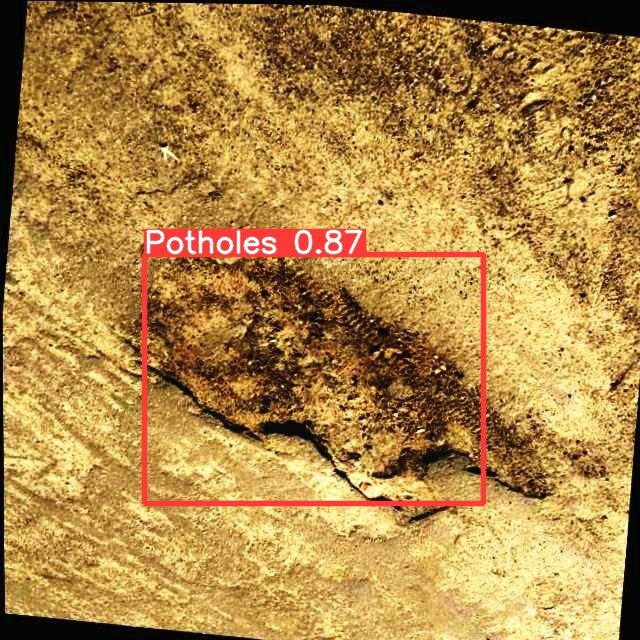

In [10]:
from IPython.display import Image, display

result_path = "/kaggle/working/inference/pothole_test/img-113_jpg.rf.4c1abb7cfef5e87cc11fff47e32fb2b4.jpg"

display(Image(filename=result_path))